# Librerías

In [1]:
# Manejo de datos
import pandas as pd                 # Análisis y manipulación de datos en tablas
import numpy as np                  # Cálculos numéricos y matrices
import os                           # Gestión de rutas de archivos

# Visualización de datos
import matplotlib.pyplot as plt     # Gráficos básicos en 2D
import seaborn as sns               # Gráficos estadísticos mejorados
import plotly.express as px         # Gráficos interactivos simplificados
import plotly.graph_objects as go   # Control avanzado de gráficos en Plotly
import plotly.io as pio             # Interfaz de entrada/salida de Plotly

# Procesado y análisis
from scipy import stats
from scipy.stats import chi2_contingency, norm, ttest_ind, f_oneway # Pruebas de hipótesis y análisis estadístico
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix,roc_curve, auc

# Widgets
import ipywidgets as widgets
from IPython.display import display

# Conexión a Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Estilo limpio y profesional
sns.set(style="whitegrid", palette="Set2")

# Ajustes generales de Matplotlib
plt.rcParams["axes.titlesize"] = 14          # Tamaño del título
plt.rcParams["axes.labelsize"] = 12          # Tamaño de las etiquetas de los ejes
plt.rcParams["xtick.labelsize"] = 10         # Tamaño de las etiquetas del eje x
plt.rcParams["ytick.labelsize"] = 10         # Tamaño de las etiquetas del eje y
plt.rcParams["legend.fontsize"] = 10         # Tamaño de fuente en la leyenda
plt.rcParams["figure.figsize"] = (10, 6)     # Tamaño por defecto de las figuras
plt.rcParams["axes.spines.top"] = False      # Quitar borde superior
plt.rcParams["axes.spines.right"] = False    # Quitar borde derecho
plt.rcParams['grid.color'] = 'lightgray'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

Mounted at /content/drive


# Carga de datos

In [ ]:
# OJO: Asegúrate de que el nombre de las carpetas sea EXACTO

# Ruta base a la carpeta
base_path = '/content/drive/MyDrive/Data Science - Grupo 4/Data/tablas_extraidas_Orphadata'

orphadata = {}
for archivo in os.listdir(base_path):
    if archivo.endswith(".csv"):
        ruta_archivo = os.path.join(base_path, archivo)
        nombre_dataframe = archivo.replace(".csv", "")
        orphadata[nombre_dataframe] = pd.read_csv(ruta_archivo)
orphadata.keys()

dict_keys(['df_rd_classification', 'df_rd_list', 'df_diseases', 'df_genes', 'df_disease_gene', 'df_rd_epidemiology', 'df_rd_history', 'df_rd_functional_consequences', 'df_rd_phenotypes'])

# Limpieza

In [3]:
# Tabla enfermedades
# df_diseases
enfermedades = orphadata['df_diseases'].copy()
enfermedades.drop(columns=['class_hchId'], inplace=True)
enfermedades = enfermedades.drop_duplicates(subset='ORPHAcode')
enfermedades = enfermedades.sort_values(by='ORPHAcode')
enfermedades = enfermedades.rename(columns={'preferredTerm': 'nombre_enfermedad'})
enfermedades.head(5)

,ORPHAcode,nombre_enfermedad
41,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...
4661,6,3-methylcrotonyl-CoA carboxylase deficiency
1170,7,3C syndrome
3208,8,"47,XYY syndrome"
3200,9,Tetrasomy X syndrome


In [4]:
# Tabla clasificación
# df_rd_list + df_rd_classification + df_diseases
clasificacion = orphadata['df_rd_list'] \
    .merge(orphadata['df_diseases'], on='ORPHAcode', how='outer')

# Rename 'class_hchId' to 'hchId' for merging with df_rd_classification
clasificacion.rename(columns={'class_hchId': 'hchId'}, inplace=True)

clasificacion = clasificacion.merge(orphadata['df_rd_classification'], on='hchId', how='left')


clasificacion.drop(columns=['Preferred term'], inplace=True)
clasificacion = clasificacion[['hchId', 'hchTag', 'ORPHAcode', 'preferredTerm']]
clasificacion = clasificacion.rename(columns={'hchId': 'clase_id', 'hchTag': 'clase','preferredTerm': 'nombre_enfermedad'})
clasificacion['clase_id'] = clasificacion['clase_id'].astype('Int64')
clasificacion = clasificacion.dropna(subset=['clase_id'])
clasificacion.loc[:, "clase"] = clasificacion["clase"].str.replace("Orphanet classification of ", "").str.capitalize()
# NO eliminar duplicados, ya que una enfermedad puede pertenecer a varias clasificaciones
clasificacion = clasificacion.drop_duplicates(subset=['ORPHAcode', 'clase_id'])
clasificacion = clasificacion.sort_values(by='ORPHAcode')
clasificacion.head(5)

,clase_id,clase,ORPHAcode,nombre_enfermedad
3,181,Rare neurological diseases,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...
4,189,Rare ophthalmic disorders,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...
5,193,Rare endocrine diseases,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...
6,233,Rare transplant-related disorders,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...
2,156,Rare genetic diseases,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...


In [ ]:
# Tabla genes
orphadata['df_genes'].rename(columns={'name': 'Gene name'}, inplace=True)
orphadata['df_genes'].rename(columns={'symbol': 'Gene symbol'}, inplace=True)
genes = orphadata['df_genes'] \
    .merge(orphadata['df_disease_gene'], on='Gene symbol', how='left')
genes = genes.drop(columns=['Gene name_y', 'ORPHAcode', 'Disorder name', 'Disorder type', 'Validation source'])
genes = genes.rename(columns={'HGNC': 'hgnc_id', 'Gene name_x': 'nombre_gen', 'Gene symbol': 'simbolo_gen', 'Gene type': 'tipo_gen', 'Gene synonyms': 'sinonimos', 'Locus': 'locus'})
genes = genes[['hgnc_id', 'simbolo_gen', 'nombre_gen', 'tipo_gen', 'sinonimos', 'locus']]
genes['hgnc_id'] = genes['hgnc_id'].astype('Int64')
genes = genes.drop_duplicates(subset='hgnc_id')
genes = genes.sort_values(by='hgnc_id')
genes.head(5)

,hgnc_id,simbolo_gen,nombre_gen,tipo_gen,sinonimos,locus
2333,20,AARS1,alanyl-tRNA synthetase 1,gene with protein product,"['AlaRS', 'CMT2N', 'alanine tRNA ligase 1, cyt...","[{'GeneLocus': '16q22.1', 'LocusKey': 1}]"
26,23,ABAT,4-aminobutyrate aminotransferase,gene with protein product,"['4-aminobutyrate transaminase', 'GABA transam...","[{'GeneLocus': '16p13.2', 'LocusKey': 1}]"
173,29,ABCA1,ATP binding cassette subfamily A member 1,gene with protein product,"['TGD', 'Tangier disease']","[{'GeneLocus': '9q31.1', 'LocusKey': 1}]"
178,32,ABCA2,ATP binding cassette subfamily A member 2,gene with protein product,NaN,"[{'GeneLocus': '9q34.3', 'LocusKey': 1}]"
179,33,ABCA3,ATP binding cassette subfamily A member 3,gene with protein product,"['ABC-C', 'EST111653', 'LBM180']","[{'GeneLocus': '16p13.3', 'LocusKey': 1}]"


In [ ]:
# Tabla enfermedad_gen
enfermedad_gen = orphadata['df_genes'] \
    .merge(orphadata['df_disease_gene'], on='Gene symbol', how='left')
enfermedad_gen = enfermedad_gen.drop(columns=['Gene name_y', 'Disorder name', 'Disorder type', 'HGNC', 'Gene name_x', 'Gene type', 'Gene synonyms', 'Locus'])
enfermedad_gen = enfermedad_gen.rename(columns={'Gene symbol': 'simbolo_gen', 'Validation source': 'fuente_info'})
enfermedad_gen = enfermedad_gen[['ORPHAcode', 'simbolo_gen', 'fuente_info']].sort_values(by='ORPHAcode')
enfermedad_gen['ORPHAcode'] = enfermedad_gen['ORPHAcode'].astype('Int64')
enfermedad_gen = enfermedad_gen[enfermedad_gen['ORPHAcode'].notna()]
enfermedad_gen = enfermedad_gen.drop(columns=['fuente_info'])
enfermedad_gen = enfermedad_gen.drop_duplicates(subset=['ORPHAcode', 'simbolo_gen'])
enfermedad_gen.head(5)

,ORPHAcode,simbolo_gen
4637,5,HADHA
5382,6,MCCC2
5381,6,MCCC1
2085,7,WASHC5
2075,7,VPS35L


In [ ]:
# Tabla enfermedades_geneticas
genes = genes.drop(columns= ['hgnc_id', 'sinonimos', 'locus', 'tipo_gen'])
enfermedades_geneticas = enfermedad_gen.merge(genes, how='left', on='simbolo_gen')
enfermedades_geneticas = enfermedades_geneticas.drop_duplicates(subset=['ORPHAcode', 'simbolo_gen'])
enfermedades_geneticas.head(5)

,ORPHAcode,simbolo_gen,nombre_gen
0,5,HADHA,hydroxyacyl-CoA dehydrogenase trifunctional mu...
1,6,MCCC2,methylcrotonyl-CoA carboxylase subunit 2
2,6,MCCC1,methylcrotonyl-CoA carboxylase subunit 1
3,7,WASHC5,WASH complex subunit 5
4,7,VPS35L,VPS35 endosomal protein sorting factor like


In [ ]:
# Tabla fenotipos
fenotipos = orphadata['df_rd_phenotypes']
fenotipos = fenotipos.drop(columns=['ORPHAcode', 'Disorder', 'Frequency'])
fenotipos = fenotipos.rename(columns={'HPO_ID': 'fenotipo_id', 'HPO_Term': 'fenotipo'})
fenotipos = fenotipos.drop_duplicates(subset='fenotipo_id')
fenotipos = fenotipos.sort_values(by='fenotipo_id')
fenotipos.head(5)

,fenotipo_id,fenotipo
36609,HP:0000002,Abnormality of body height
3031,HP:0000003,Multicystic kidney dysplasia
1160,HP:0000008,Abnormal morphology of female internal genitalia
21886,HP:0000009,Functional abnormality of the bladder
1606,HP:0000010,Recurrent urinary tract infections


In [ ]:
# Tabla enfermedad_fenotipo
enfermedad_fenotipo = orphadata['df_rd_phenotypes']
enfermedad_fenotipo = enfermedad_fenotipo.drop(columns=['Disorder', 'HPO_Term'])
enfermedad_fenotipo = enfermedad_fenotipo.rename(columns={'HPO_ID': 'fenotipo_id', 'Frequency': 'frecuencia'})
enfermedad_fenotipo = enfermedad_fenotipo.drop_duplicates(subset=['ORPHAcode', 'fenotipo_id'])
enfermedad_fenotipo.head(5)

,ORPHAcode,fenotipo_id,frecuencia
0,58,HP:0000256,Very frequent (99-80%)
1,58,HP:0001249,Very frequent (99-80%)
2,58,HP:0001250,Very frequent (99-80%)
3,58,HP:0001257,Very frequent (99-80%)
4,58,HP:0001274,Very frequent (99-80%)


In [ ]:
# Tabla fenotipos_final
fenotipos_final = enfermedad_fenotipo.merge(fenotipos, on='fenotipo_id', how='left')
fenotipos_final = fenotipos_final.drop(columns=['fenotipo'])
fenotipos_final.head(5)

,ORPHAcode,fenotipo_id,frecuencia
0,58,HP:0000256,Very frequent (99-80%)
1,58,HP:0001249,Very frequent (99-80%)
2,58,HP:0001250,Very frequent (99-80%)
3,58,HP:0001257,Very frequent (99-80%)
4,58,HP:0001274,Very frequent (99-80%)


In [ ]:
# Tabla epidemiología
orphadata['df_rd_epidemiology'].rename(columns={'Code Disease': 'ORPHAcode'}, inplace=True)
epidemiologia = orphadata['df_rd_epidemiology']
epidemiologia = epidemiologia.rename(columns={'Typology': 'tipo_enfermedad', 'PrevalenceType': 'prevalencia_tipo', 'Preferred term': 'nombre_enfermedad', 'ValMoy': 'prevalencia_promedio', 'PrevalenceClass': 'prevalencia_clase', 'PrevalenceQualification': 'calidad_prevalencia', 'PrevalenceGeographic': 'region_prevalencia', 'PrevalenceValidationStatus': 'estado_validacion_prevalencia', 'Source': 'fuente'})
clase_a_num = {"<1 / 1 000 000": 1 / 1000000,"1-9 / 1 000 000": 5 / 1000000,"1-9 / 100 000": 5 / 100000,"1-5 / 10 000": 3 / 10000,"6-9 / 10 000": 7.5 / 10000,">1 / 1000": 2 / 1000,"Unknown": np.nan,"Not yet documented": np.nan}
epidemiologia['prevalencia_clase_num'] = epidemiologia['prevalencia_clase'].map(clase_a_num)
epidemiologia['prevalencia_final'] = epidemiologia['prevalencia_promedio'].where(
    epidemiologia['prevalencia_promedio'] > 0,
    epidemiologia['prevalencia_clase_num']
)
epidemiologia = epidemiologia.drop(columns=['prevalencia_promedio', 'prevalencia_clase', 'prevalencia_clase_num'])
epidemiologia = epidemiologia[['ORPHAcode', 'nombre_enfermedad', 'tipo_enfermedad', 'prevalencia_tipo', 'prevalencia_final', 'region_prevalencia', 'calidad_prevalencia', 'estado_validacion_prevalencia']]
epidemiologia = epidemiologia.dropna(subset=['estado_validacion_prevalencia'])
epidemiologia.head(5)

,ORPHAcode,nombre_enfermedad,tipo_enfermedad,prevalencia_tipo,prevalencia_final,region_prevalencia,calidad_prevalencia,estado_validacion_prevalencia
0,166024,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease,Cases/families,4.000000,Worldwide,Case(s),Validated
1,166024,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease,Point prevalence,0.000001,Worldwide,Class only,Validated
2,58,Alexander disease,Disease,Annual incidence,0.037000,Japan,Value and class,Validated
3,58,Alexander disease,Disease,Point prevalence,NaN,Worldwide,Class only,Not yet validated
4,166032,Multiple epiphyseal dysplasia-miniepiphyses sy...,Disease,Cases/families,2.000000,Worldwide,Case(s),Validated


In [ ]:
# Tabla historia
historia = orphadata['df_rd_history']
historia = historia.drop(columns=['data', 'Date', 'OrphanetURL', 'DisorderGroup'])
historia = historia.rename(columns={'AverageAgeOfOnset': 'edad_media_inicio', 'TypeOfInheritance': 'tipo_herencia', 'Typology': 'tipo_enfermedad', 'Preferred term': 'nombre_enfermedad'})
historia = historia[['ORPHAcode', 'nombre_enfermedad', 'tipo_enfermedad', 'edad_media_inicio', 'tipo_herencia']]
import ast
def safe_literal_eval(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x_clean = x.strip()
        if x_clean in ["", "[]"]:
            return []
        try:
            return ast.literal_eval(x_clean)
        except (ValueError, SyntaxError):
            return []
    return []
historia['edad_media_inicio'] = historia['edad_media_inicio'].apply(safe_literal_eval)
historia.head(5)

,ORPHAcode,nombre_enfermedad,tipo_enfermedad,edad_media_inicio,tipo_herencia
0,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...,Disease,"[Infancy, Neonatal]",['Autosomal recessive']
1,6,3-methylcrotonyl-CoA carboxylase deficiency,Disease,[All ages],['Autosomal recessive']
2,7,3C syndrome,Malformation syndrome,"[Antenatal, Infancy, Neonatal]","['Autosomal recessive', 'X-linked recessive']"
3,8,"47,XYY syndrome",Malformation syndrome,[All ages],"['Not applicable', 'Unknown']"
4,9,Tetrasomy X syndrome,Malformation syndrome,"[Infancy, Neonatal]",NaN


# Análisis exploratorio

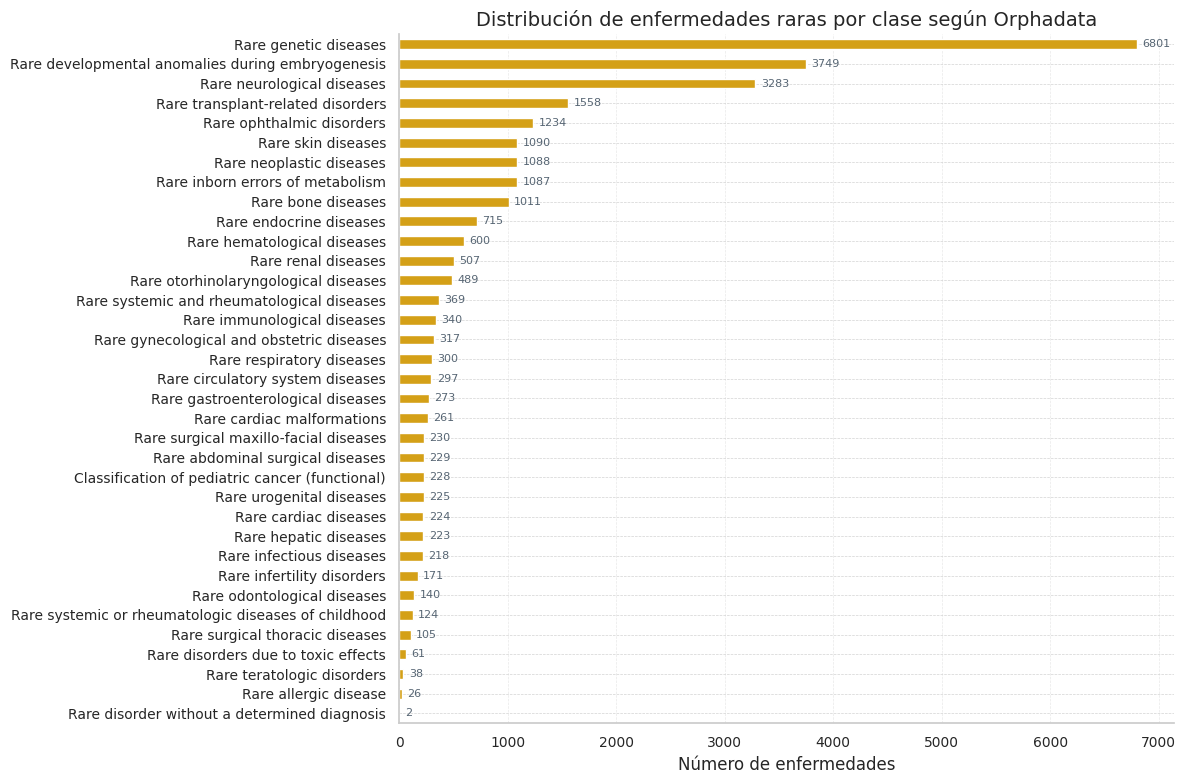

In [ ]:
# Distribución de enfermedades por clase
conteo_clases = clasificacion.groupby("clase")["nombre_enfermedad"].count().sort_values()
fig, ax = plt.subplots(figsize=(12, 8))
conteo_clases.plot.barh(ax=ax, color="#d4a017", title="Distribución de enfermedades raras por clase según Orphadata")
ax.set_xlabel("Número de enfermedades")
ax.set_ylabel("")
plt.tight_layout()
plt.grid(axis="x", linestyle="--", alpha=0.5)
for i, v in enumerate(conteo_clases.values):
    plt.text(v + 50, i, f"{v}", va='center', fontsize=8, color='#566573')
plt.show()

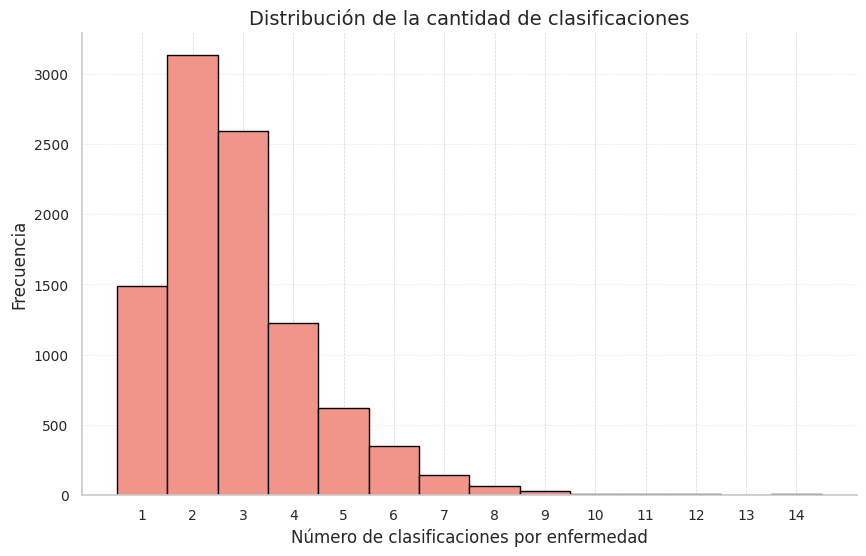

In [ ]:
# Clasificación por número de clases
conteo_clasificacion = clasificacion.groupby('ORPHAcode').size().reset_index(name='cantidad_clasificaciones')
max_val = conteo_clasificacion['cantidad_clasificaciones'].max()
bins = np.arange(1, max_val + 2)
plt.hist(conteo_clasificacion['cantidad_clasificaciones'], bins=bins, edgecolor='black', align='left', color='#f1948a')
plt.xlabel('Número de clasificaciones por enfermedad')
plt.ylabel('Frecuencia')
plt.title('Distribución de la cantidad de clasificaciones')
plt.xticks(bins[:-1])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

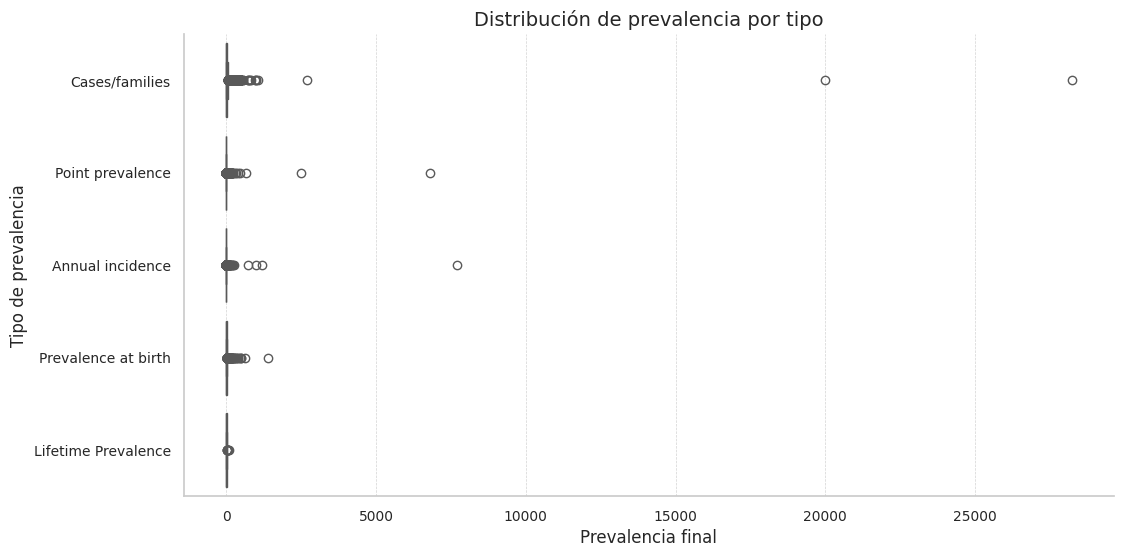

In [ ]:
# Distribución de prevalencia por tipo
plt.figure(figsize=(12, 6))
sns.boxplot(data=epidemiologia, y='prevalencia_tipo', x='prevalencia_final')
plt.title('Distribución de prevalencia por tipo')
plt.xlabel('Prevalencia final')
plt.ylabel('Tipo de prevalencia')
plt.show()

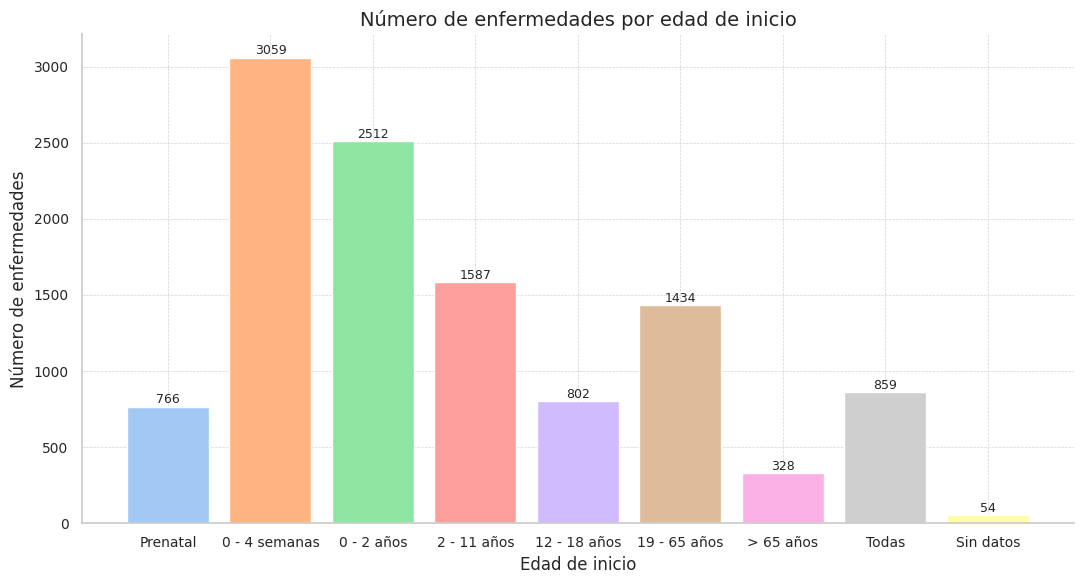

In [ ]:
# Número de enfermedades por edad de inicio
etapas = set()
historia['edad_media_inicio'].apply(etapas.update)
edad_inicio_binaria = historia[['ORPHAcode']].copy()
for etapa in etapas:
    edad_inicio_binaria[etapa] = historia['edad_media_inicio'].apply(lambda x: int(etapa in x))
orden_etapas = ['Antenatal', 'Neonatal', 'Infancy', 'Childhood', 'Adolescent', 'Adult', 'Elderly', 'All ages', 'No data available']
etiquetas_mostrar = {
    'Antenatal': 'Prenatal', 'Neonatal': '0 - 4 semanas', 'Infancy': '0 - 2 años',
    'Childhood': '2 - 11 años', 'Adolescent': '12 - 18 años', 'Adult': '19 - 65 años',
    'Elderly': '> 65 años', 'All ages': 'Todas', 'No data available': 'Sin datos'
}
conteo_etapas = edad_inicio_binaria[orden_etapas].sum().rename(index=etiquetas_mostrar)
# plt.figure(figsize=(10, 6))
# conteo_etapas.plot(kind='bar')

# Paleta pastel
colores = sns.color_palette('pastel')

plt.figure(figsize=(11, 6))
bars = plt.bar(conteo_etapas.index, conteo_etapas.values, color=colores[:len(conteo_etapas)])

# Añadir etiquetas encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=9)

plt.title('Número de enfermedades por edad de inicio')
plt.xlabel('Edad de inicio')
plt.ylabel('Número de enfermedades')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


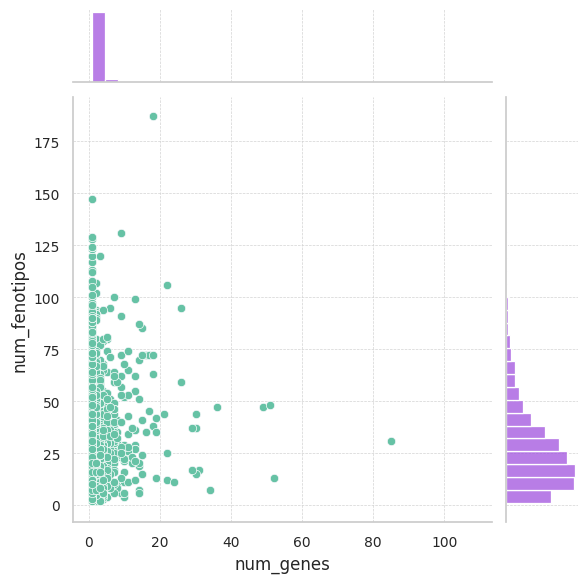

In [ ]:
# Complejidad genética y fenotípica
fenotipos_por_enf = fenotipos_final.groupby('ORPHAcode')['fenotipo_id'].nunique()
genes_por_enf = enfermedades_geneticas.groupby('ORPHAcode')['simbolo_gen'].nunique()
df_complejidad = pd.DataFrame({
    'num_fenotipos': fenotipos_por_enf,
    'num_genes': genes_por_enf
}).reset_index()
sns.jointplot(
    data=df_complejidad,
    x="num_genes",
    y="num_fenotipos",
    kind="scatter",
    marginal_kws=dict(bins=30, fill=True),
    color='#a052de',
    alpha=0.6
).plot_joint(sns.scatterplot)
plt.show()

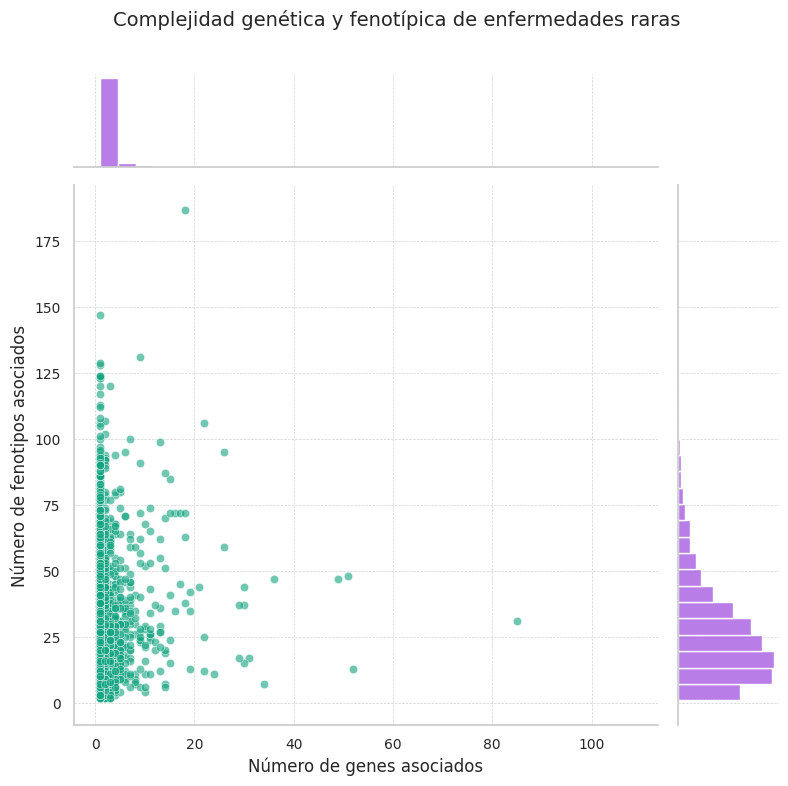

In [ ]:
# Complejidad genética y fenotípica

# Construcción del dataframe
fenotipos_por_enf = fenotipos_final.groupby('ORPHAcode')['fenotipo_id'].nunique()
genes_por_enf = enfermedades_geneticas.groupby('ORPHAcode')['simbolo_gen'].nunique()
df_complejidad = pd.DataFrame({
    'num_fenotipos': fenotipos_por_enf,
    'num_genes': genes_por_enf
}).reset_index()

# Definir color personalizado
color_personalizado = '#a052de'

# Crear jointplot con color uniforme
g = sns.jointplot(
    data=df_complejidad,
    x="num_genes",
    y="num_fenotipos",
    kind="scatter",
    marginal_kws=dict(bins=30, fill=True, color=color_personalizado),
    color='#10A37F',
    alpha=0.6,
    height=8
)

# Ejes y título
g.set_axis_labels("Número de genes asociados", "Número de fenotipos asociados", fontsize=12)
plt.suptitle("Complejidad genética y fenotípica de enfermedades raras", fontsize=14)
plt.subplots_adjust(top=0.9)
plt.show()


/tmp/ipython-input-18-3985425847.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_gene, x='Num_gens', y='Disorder name', palette='viridis')


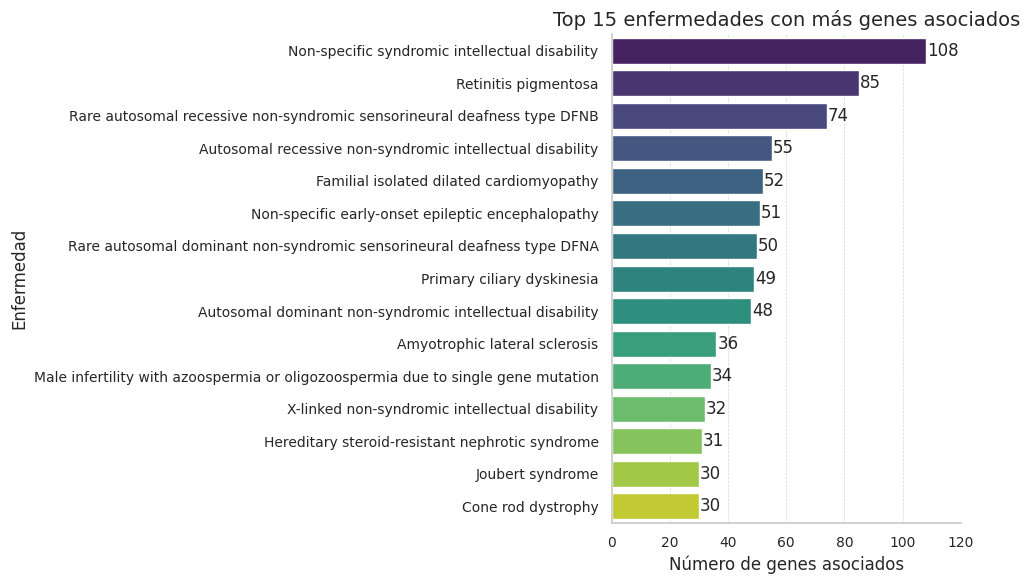

In [ ]:
# Agrupar por enfermedad y contar genes únicos
df_gene = orphadata['df_disease_gene'].groupby('Disorder name')['Gene symbol'].nunique().reset_index()
df_gene = df_gene.rename(columns={'Gene symbol': 'Num_gens'})
df_gene = df_gene.sort_values('Num_gens', ascending=False).head(15)

# Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_gene, x='Num_gens', y='Disorder name', palette='viridis')

# Añadir etiquetas con el número de genes
for i, value in enumerate(df_gene['Num_gens']):
    ax.text(value + 0.3, i, str(value), va='center')

# Etiquetas y formato
plt.xlabel('Número de genes asociados')
plt.ylabel('Enfermedad')
plt.xlim(0, 120)
plt.title('Top 15 enfermedades con más genes asociados')
plt.tight_layout()
plt.show()

/tmp/ipython-input-19-2016665795.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_gene, x='Num_enfermedades', y='Gene symbol', palette='crest')


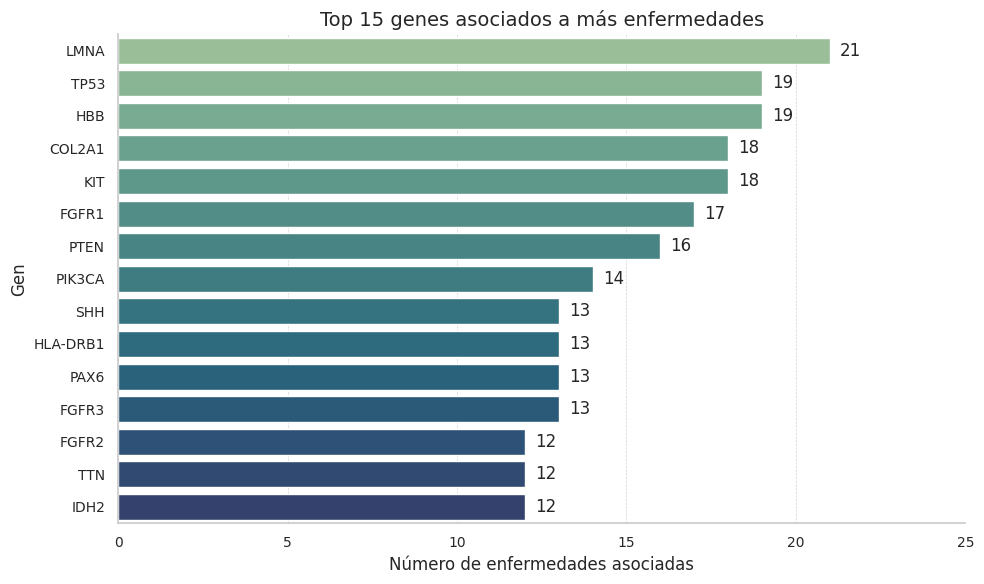

In [ ]:
# Genes asociados a más enfermedades (gráfico)
df_gene = orphadata['df_disease_gene'].groupby('Gene symbol')['ORPHAcode'].nunique().reset_index()
df_gene = df_gene.rename(columns={'ORPHAcode': 'Num_enfermedades'})
df_gene = df_gene.sort_values('Num_enfermedades', ascending=False).head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_gene, x='Num_enfermedades', y='Gene symbol', palette='crest')
ax.xaxis.get_major_locator().set_params(integer=True)

# Etiquetas con valores
for i, value in enumerate(df_gene['Num_enfermedades']):
    ax.text(value + 0.3, i, str(value), va='center')

plt.xlabel('Número de enfermedades asociadas')
plt.xlim(0, 25)
plt.ylabel('Gen')
plt.title('Top 15 genes asociados a más enfermedades')
plt.tight_layout()
plt.show()

/tmp/ipython-input-96-2836075930.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-96-2836075930.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




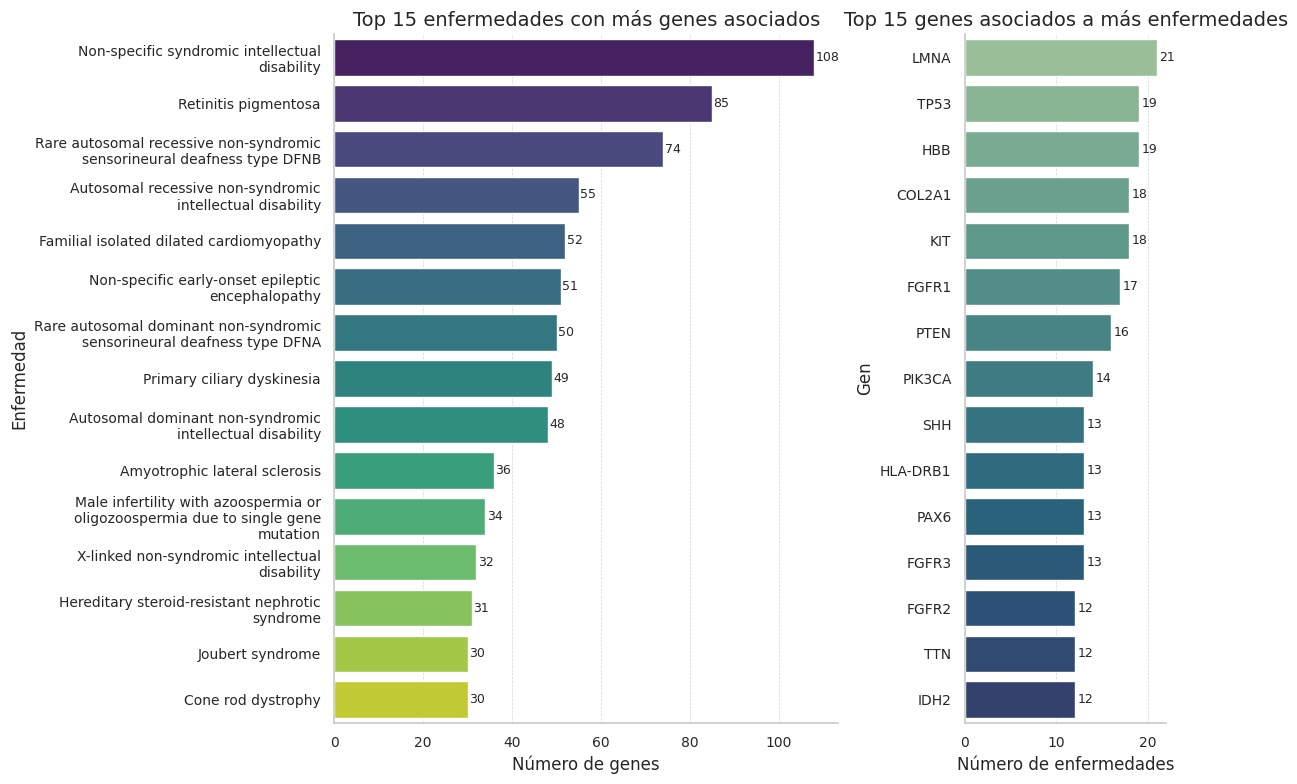

In [ ]:
# Juntos

import textwrap

# Datos 1: enfermedades con más genes
df_enf = orphadata['df_disease_gene'].groupby('Disorder name')['Gene symbol'].nunique().reset_index()
df_enf = df_enf.rename(columns={'Gene symbol': 'Num_genes'})
df_enf = df_enf.sort_values('Num_genes', ascending=False).head(15)
df_enf['Disorder name'] = df_enf['Disorder name'].apply(lambda x: '\n'.join(textwrap.wrap(x, width=40)))

# Datos 2: genes asociados a más enfermedades
df_genes = orphadata['df_disease_gene'].groupby('Gene symbol')['ORPHAcode'].nunique().reset_index()
df_genes = df_genes.rename(columns={'ORPHAcode': 'Num_enfermedades'})
df_genes = df_genes.sort_values('Num_enfermedades', ascending=False).head(15)

# Crear subplots
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 8),
    gridspec_kw={'width_ratios': [2.5, 1]}  # Primer gráfico más ancho
)

# Gráfico 1: enfermedades con más genes
sns.barplot(data=df_enf, x='Num_genes', y='Disorder name', palette='viridis', ax=axes[0])
axes[0].set_title('Top 15 enfermedades con más genes asociados')
axes[0].set_xlabel('Número de genes')
axes[0].set_ylabel('Enfermedad')
for i, value in enumerate(df_enf['Num_genes']):
    axes[0].text(value + 0.3, i, str(value), va='center', fontsize=9)

# Gráfico 2: genes asociados a más enfermedades
sns.barplot(data=df_genes, x='Num_enfermedades', y='Gene symbol', palette='crest', ax=axes[1])
axes[1].set_title('Top 15 genes asociados a más enfermedades')
axes[1].set_xlabel('Número de enfermedades')
axes[1].set_ylabel('Gen')
axes[1].xaxis.get_major_locator().set_params(integer=True)
for i, value in enumerate(df_genes['Num_enfermedades']):
    axes[1].text(value + 0.3, i, str(value), va='center', fontsize=9)

# Ajustes finales
plt.tight_layout()
plt.show()

/tmp/ipython-input-20-2645106428.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


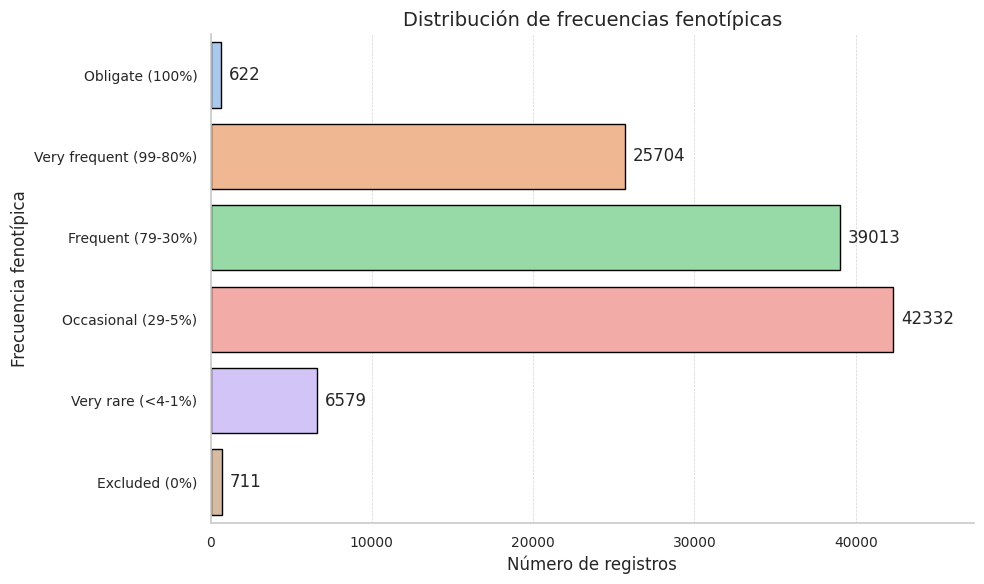

In [ ]:
# Distribución de frecuencias
# Datos
df_pheno = orphadata['df_rd_phenotypes']

# Orden clínico exacto (según lo que mostraste en la imagen)
orden_frecuencias = [
    'Obligate (100%)',
    'Very frequent (99-80%)',
    'Frequent (79-30%)',
    'Occasional (29-5%)',
    'Very rare (<4-1%)',
    'Excluded (0%)'
]

# Crear gráfico con Seaborn
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df_pheno,
    y='Frequency',
    order=orden_frecuencias,
    palette='pastel',
    edgecolor='black'
)

# Añadir etiquetas con los valores
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 500, p.get_y() + p.get_height()/2, int(width), va='center')

# Títulos y ejes
plt.title('Distribución de frecuencias fenotípicas', fontsize=14)
plt.xlabel('Número de registros', fontsize=12)
plt.ylabel('Frecuencia fenotípica', fontsize=12)
plt.xlim(0, df_pheno['Frequency'].value_counts().max() + 5000)
plt.tight_layout()
plt.show()


In [ ]:
# Clasificación por prevalencia media de fenotipos
map_freq = {
    "Very frequent (99-80%)": 0.9,
    "Frequent (79-30%)": 0.55,
    "Occasional (29-5%)": 0.17,
    "Very rare (<4%)": 0.02
}
df_pheno['Freq_num'] = df_pheno['Frequency'].map(map_freq)
df_agg = df_pheno.groupby(['ORPHAcode', 'Disorder'])['Freq_num'].mean().reset_index().sort_values(by='Freq_num', ascending=False)
print(df_agg.head(20))
print(df_agg.tail(20))

      ORPHAcode                                           Disorder  Freq_num
3886     397725         COASY protein-associated neurodegeneration       0.9
2452      86822  Lissencephaly type 3-metacarpal bone dysplasia...       0.9
720        1133                                   AREDYLD syndrome       0.9
3375     238459                                        SLC35A1-CDG       0.9
1230       2163        Holoprosencephaly-craniosynostosis syndrome       0.9
1236       2176                      Infantile systemic hyalinosis       0.9
2246      79238                     Galactose epimerase deficiency       0.9
245         335                   Congenital fibrinogen deficiency       0.9
871        1437                         Ring chromosome 1 syndrome       0.9
816        1326         Camptodactyly syndrome, Guadalajara type 2       0.9
2379      85173                                     IMAGe syndrome       0.9
2383      85184  Craniometadiaphyseal dysplasia, wormian bone type       0.9

In [ ]:
# Fenotipo principal por enfermedad
df_pheno = df_pheno.dropna(subset=['Freq_num'])
idx = df_pheno.groupby('ORPHAcode')['Freq_num'].idxmax()
fenotip_principal = df_pheno.loc[idx, ['ORPHAcode', 'Disorder', 'HPO_Term', 'Freq_num']]
print(fenotip_principal.head(20))

        ORPHAcode                                           Disorder  \
52104           5  Long chain 3-hydroxyacyl-CoA dehydrogenase def...   
25640           6        3-methylcrotonyl-CoA carboxylase deficiency   
11913           7                                        3C syndrome   
37523           8                                    47,XYY syndrome   
5423            9                               Tetrasomy X syndrome   
11584          10                                   48,XXYY syndrome   
4848           11                               Pentasomy X syndrome   
49568          13    6-pyruvoyl-tetrahydropterin synthase deficiency   
3764           14                               Abetalipoproteinemia   
76534          15                                     Achondroplasia   
2246           16                           Blue cone monochromatism   
107803         17  Fatal infantile lactic acidosis with methylmal...   
86218          18                      Distal renal tubular acid

In [ ]:
# Fenotipos con frecuencia máxima (posibles empates)
fenotips_principals = []
for orpha, group in df_pheno.groupby('ORPHAcode'):
    max_freq = group['Freq_num'].max()
    fenotips_principals.append(group[group['Freq_num'] == max_freq])
fenotips_principals_df = pd.concat(fenotips_principals)
print(fenotips_principals_df[['ORPHAcode', 'Disorder', 'HPO_Term', 'Freq_num']])

        ORPHAcode                                           Disorder  \
52104           5  Long chain 3-hydroxyacyl-CoA dehydrogenase def...   
52105           5  Long chain 3-hydroxyacyl-CoA dehydrogenase def...   
52106           5  Long chain 3-hydroxyacyl-CoA dehydrogenase def...   
25640           6        3-methylcrotonyl-CoA carboxylase deficiency   
25643           6        3-methylcrotonyl-CoA carboxylase deficiency   
...           ...                                                ...   
106419     658549                 Idiopathic small fibers neuropathy   
106227     664372                         Soft and hard cleft palate   
106228     664372                         Soft and hard cleft palate   
106229     664372                         Soft and hard cleft palate   
107050     685082      Pediatric acute respiratory distress syndrome   

                          HPO_Term  Freq_num  
52104                  Photophobia      0.90  
52105                 Hypoglycemia      0

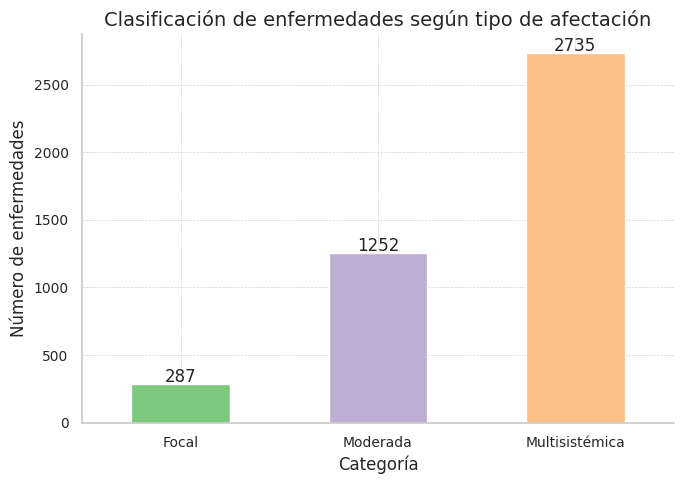

In [ ]:
# Clasificación multisistémica
grouped = df_pheno.groupby(['ORPHAcode', 'Disorder'])['HPO_ID'].nunique().reset_index()
grouped.rename(columns={'HPO_ID': 'Num_fenotips'}, inplace=True)

def categoritzar(num):
    if num <= 5:
        return 'Focal'
    elif num <= 15:
        return 'Moderada'
    else:
        return 'Multisistémica'

grouped['Categoria'] = grouped['Num_fenotips'].apply(categoritzar)

# Contar cuántas enfermedades hay por categoría
comptes = grouped['Categoria'].value_counts().sort_index()  # Ordenar por nombre de categoría si se desea consistencia

# Crear gráfico
fig, ax = plt.subplots(figsize=(7, 5))
comptes.plot(kind='bar', color=['#7fc97f','#beaed4','#fdc086'], ax=ax)

plt.title('Clasificación de enfermedades según tipo de afectación')
plt.xlabel('Categoría')
plt.ylabel('Número de enfermedades')
plt.xticks(rotation=0)

# Añadir etiquetas encima de las barras
for i, value in enumerate(comptes):
    ax.text(i, value + 15, str(value), ha='center')

plt.tight_layout()
plt.show()


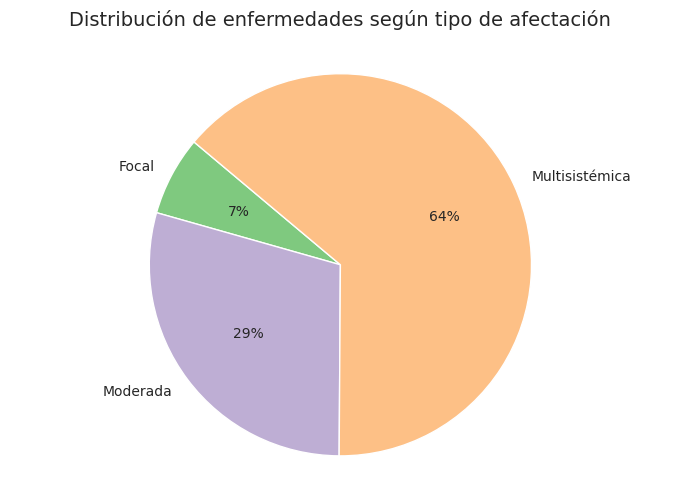

In [ ]:
# Crear gráfico de pastel
colors = ['#7fc97f', '#beaed4', '#fdc086']
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(
    comptes.values,
    labels=comptes.index,
    autopct=lambda p: f'{int(round(p))}%' if p > 0 else '',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 10}
)
ax.set_title('Distribución de enfermedades según tipo de afectación', y=1.05)
ax.axis('equal')  # Para que el pie chart sea circular

plt.tight_layout()
plt.show()

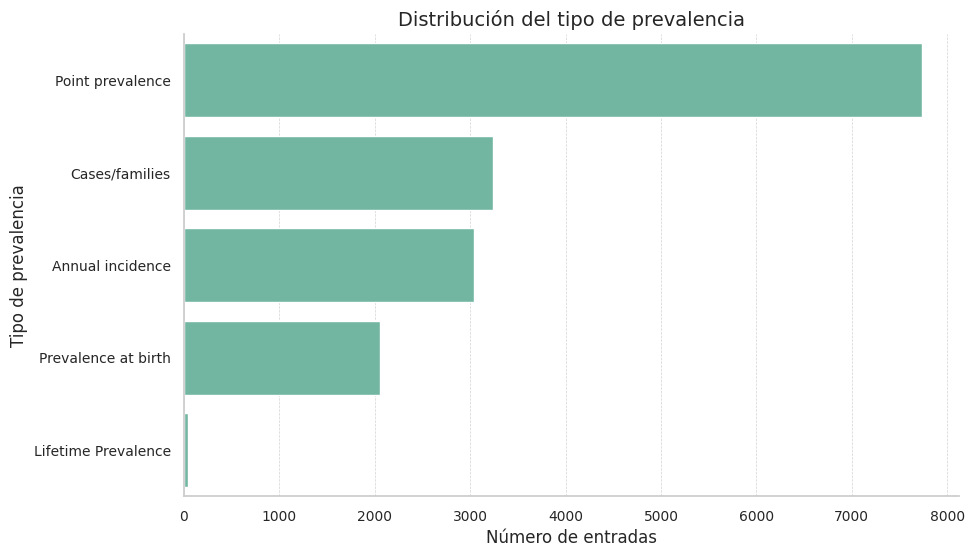

In [ ]:
# Distribución del tipo de prevalencia mundial
df_epi = orphadata['df_rd_epidemiology']
sns.countplot(data=df_epi, y='PrevalenceType', order=df_epi['PrevalenceType'].value_counts().index)
plt.title("Distribución del tipo de prevalencia")
plt.xlabel("Número de entradas")
plt.ylabel("Tipo de prevalencia")
plt.show()

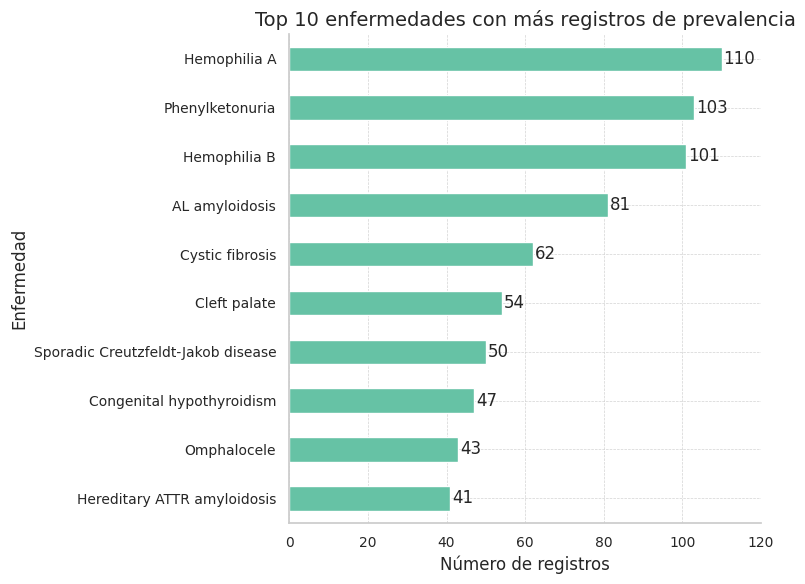

In [ ]:
# Top enfermedades por registros de prevalencia
top_disorders = df_epi['Preferred term'].value_counts().head(10)
top_disorders = top_disorders.sort_values(ascending=True)  # Para que mayor esté arriba en el barh

# Crear gráfico
ax = top_disorders.plot(kind='barh', figsize=(8,6))
plt.xlim(0, 120)
plt.title("Top 10 enfermedades con más registros de prevalencia")
plt.xlabel("Número de registros")
plt.ylabel("Enfermedad")

# Añadir etiquetas con el número de registros
for i, v in enumerate(top_disorders):
    ax.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()

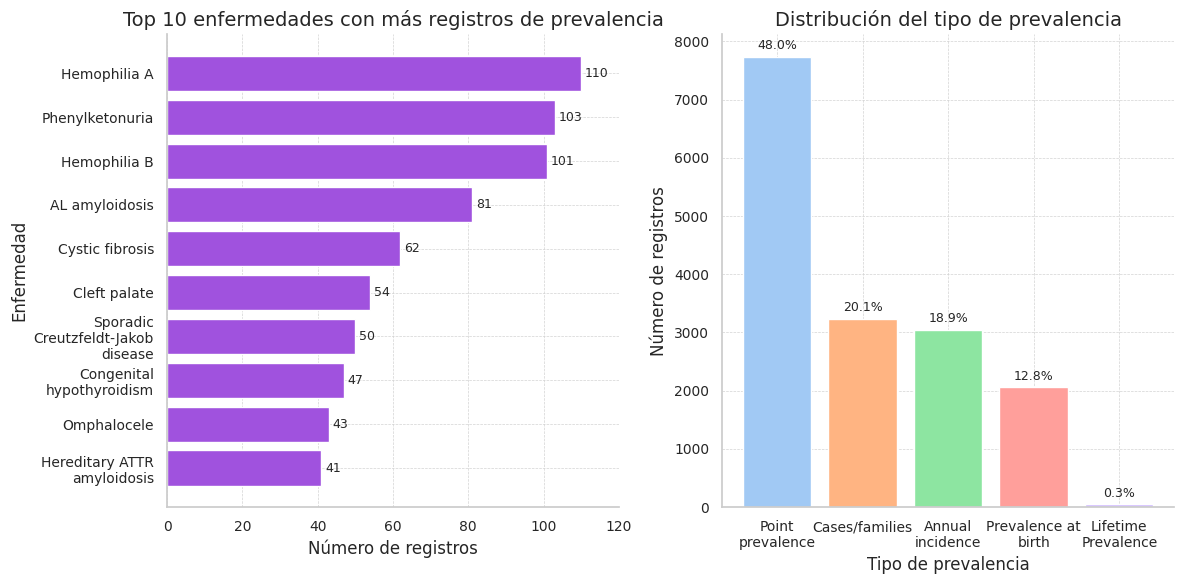

In [ ]:
# Preparar datos
df_epi = orphadata['df_rd_epidemiology']

# Top 10 enfermedades con más registros
top_disorders = df_epi['Preferred term'].value_counts().head(10).sort_values(ascending=True)

# Distribución de tipos de prevalencia
prevalence_counts = df_epi['PrevalenceType'].value_counts()
prevalence_percentages = prevalence_counts / prevalence_counts.sum() * 100

# Función para dividir texto en dos líneas
def dividir_lineas(texto, ancho=20):
    return '\n'.join(textwrap.wrap(texto, width=ancho))

# Aplicar formato a nombres
labels_dos_lineas = [dividir_lineas(name) for name in top_disorders.index]
prevalence_labels = [dividir_lineas(name, 15) for name in prevalence_counts.index]

# Crear subplots horizontales
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1]})

# --- Subplot 1: Top enfermedades ---
axes[0].barh(labels_dos_lineas, top_disorders.values, color='#a052de')
axes[0].set_title("Top 10 enfermedades con más registros de prevalencia")
axes[0].set_xlabel("Número de registros")
axes[0].set_ylabel("Enfermedad")
axes[0].set_xlim(0, top_disorders.max() + 10)
for i, v in enumerate(top_disorders.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

# --- Subplot 2: Tipos de prevalencia ---
colors2 = sns.color_palette("pastel")
bars = axes[1].bar(prevalence_labels, prevalence_counts.values, color=colors2[:len(prevalence_counts)])
axes[1].set_title("Distribución del tipo de prevalencia")
axes[1].set_xlabel("Tipo de prevalencia")
axes[1].set_ylabel("Número de registros")
axes[1].tick_params(axis='x', rotation=0)

# Añadir etiquetas con porcentaje
for bar, pct in zip(bars, prevalence_percentages):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height + max(prevalence_counts.values) * 0.01,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

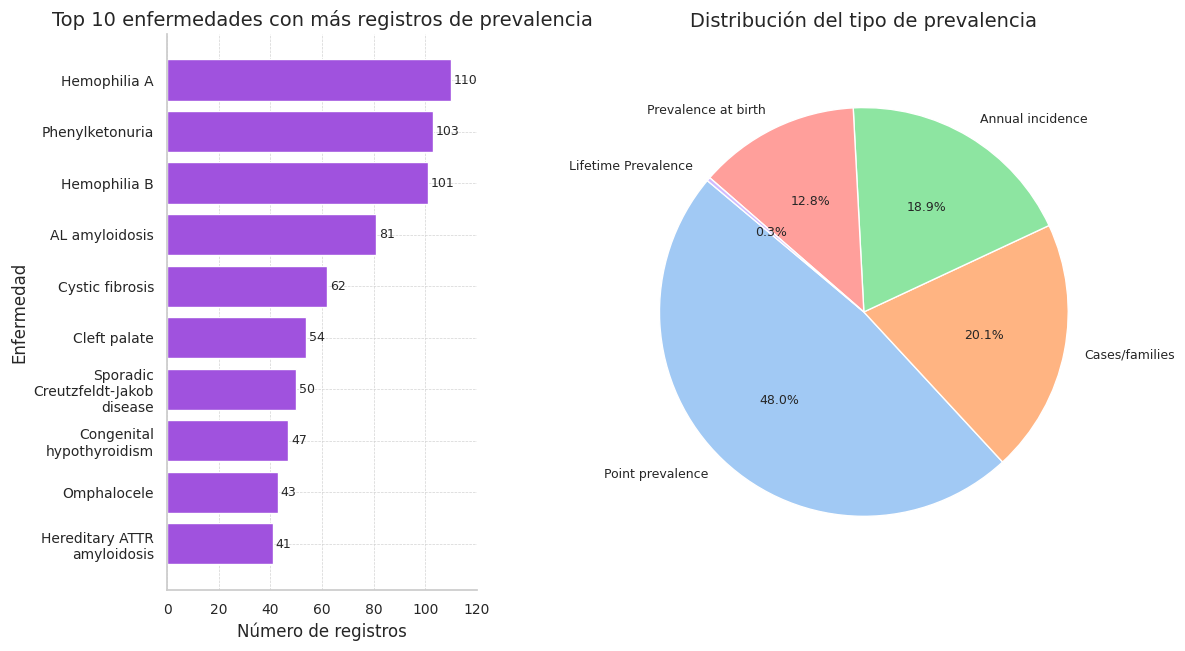

In [ ]:
# Datos
df_epi = orphadata['df_rd_epidemiology']
top_disorders = df_epi['Preferred term'].value_counts().head(10).sort_values(ascending=True)
prevalence_counts = df_epi['PrevalenceType'].value_counts()

# Dividir en dos líneas si el nombre es muy largo
def dividir_lineas(texto, ancho=20):
    return '\n'.join(textwrap.wrap(texto, width=ancho))

# Aplicar formato a nombres
labels_dos_lineas = [dividir_lineas(name) for name in top_disorders.index]

# Crear figura con proporciones ajustadas
fig, axes = plt.subplots(1, 2, figsize=(12, 7), gridspec_kw={'width_ratios': [1.2, 1.8]})

# Paleta pastel
colors = sns.color_palette("pastel")

# Gráfico de barras (Top 10 enfermedades)
axes[0].barh(labels_dos_lineas, top_disorders.values, color='#a052de')
axes[0].set_title("Top 10 enfermedades con más registros de prevalencia")
axes[0].set_xlabel("Número de registros")
axes[0].set_ylabel("Enfermedad")
axes[0].set_xlim(0, top_disorders.max() + 10)
for i, v in enumerate(top_disorders.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

# Pie chart con mayor radio
axes[1].pie(
    prevalence_counts.values,
    labels=prevalence_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 9},
    radius=1.1
)
axes[1].set_title("Distribución del tipo de prevalencia", y=1.096)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

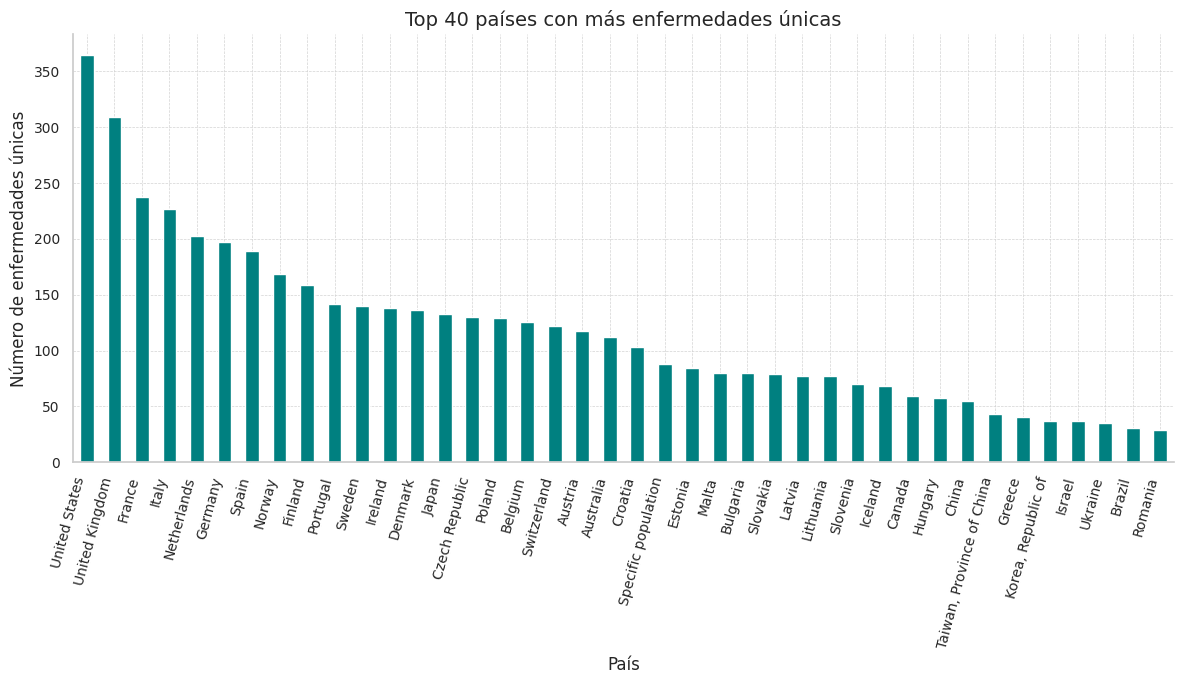

In [ ]:
# Países con más enfermedades únicas
excluir = ['Europe', 'Africa', 'Worldwide', 'Asia', 'North America', 'South America','Oceania', 'Middle East', 'Central America', 'Eastern Europe', 'Western Europe','Northern Europe', 'Southern Europe', 'Sub-Saharan Africa', 'Central Africa','Northern Africa', 'Southern Africa', 'Eastern Africa', 'Western Africa','Southeast Asia']
df_paises = df_epi[~df_epi['PrevalenceGeographic'].isin(excluir)]
conteo_geo = df_paises.groupby('PrevalenceGeographic')['ORPHAcode'].nunique().sort_values(ascending=False)
conteo_top40 = conteo_geo.head(40)
plt.figure(figsize=(12,7))
conteo_top40.plot(kind='bar', color='teal')
plt.title('Top 40 países con más enfermedades únicas')
plt.xlabel('País')
plt.ylabel('Número de enfermedades únicas')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
excluir = ['Europe', 'Africa', 'Worldwide', 'Asia', 'North America', 'South America','Oceania', 'Middle East', 'Central America', 'Eastern Europe', 'Western Europe','Northern Europe', 'Southern Europe', 'Sub-Saharan Africa', 'Central Africa','Northern Africa', 'Southern Africa', 'Eastern Africa', 'Western Africa','Southeast Asia']
df_epi = orphadata['df_rd_epidemiology']
df_paises = df_epi[~df_epi['PrevalenceGeographic'].isin(excluir)]
conteo_geo = df_paises.groupby('PrevalenceGeographic')['ORPHAcode'].nunique().reset_index()
conteo_geo.columns = ['country', 'unique_diseases']

fig = px.choropleth(
    conteo_geo,
    locations='country',
    locationmode='country names',
    color='unique_diseases',
    color_continuous_scale='Mint',
    labels={'unique_diseases': 'Enfermedades', 'country': 'País'},  # Etiqueta personalizada
    title='Número de enfermedades raras únicas por país'
)
fig.update_geos(showcoastlines=True, showcountries=True)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0},
                  coloraxis_colorbar=dict(x=0.88),
                  title=dict(x=0.5,xanchor='center')
                )
fig.show()

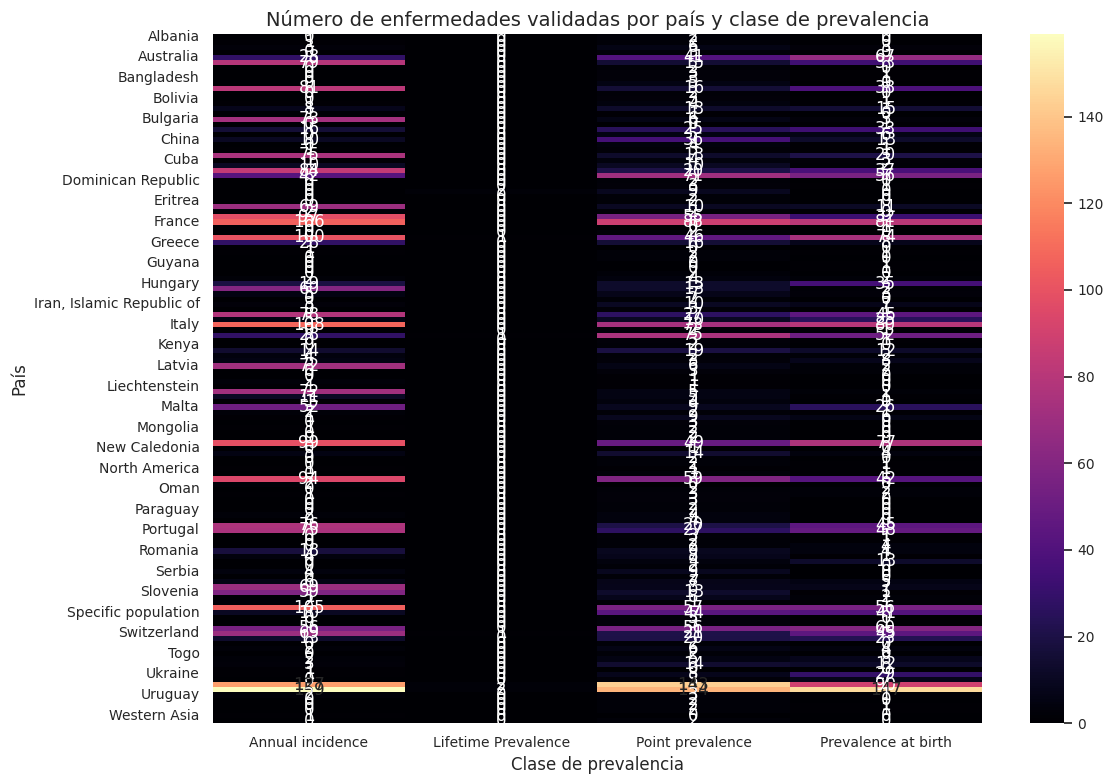

In [ ]:
# Clasificación por país según tipo de prevalencia
df_filtrado = df_epi[~df_epi['PrevalenceGeographic'].isin(['Europe', 'Africa', 'Worldwide'])]
tabla_cruzada = df_filtrado.groupby(['PrevalenceGeographic', 'PrevalenceType'])['ORPHAcode'].nunique().reset_index()
tabla_cruzada = tabla_cruzada.rename(columns={'ORPHAcode': 'Num_Enfermedades'})
tabla_pivot = tabla_cruzada.pivot(index='PrevalenceGeographic', columns='PrevalenceType', values='Num_Enfermedades').fillna(0)
plt.figure(figsize=(12,8))
sns.heatmap(tabla_pivot, annot=True, fmt=".0f", cmap='magma')
plt.title('Número de enfermedades validadas por país y clase de prevalencia')
plt.ylabel('País')
plt.xlabel('Clase de prevalencia')
plt.tight_layout()
plt.show()

# Widgets interactivos

In [ ]:
# Widget para consultar categoría multisistémica por enfermedad
from IPython.display import display
import ipywidgets as widgets

# Añadimos la categoría al dataframe original para consulta
orphadata['df_rd_phenotypes'] = orphadata['df_rd_phenotypes'].merge(
    grouped[['ORPHAcode', 'Categoria']], on='ORPHAcode', how='left')

enfermedades = orphadata['df_rd_phenotypes']['Disorder'].sort_values().unique()
dropdown = widgets.Combobox(
    placeholder='Escribe o selecciona una enfermedad',
    options=enfermedades.tolist(),
    description='Enfermedad:',
    ensure_option=True,
    continuous_update=False,
    layout=widgets.Layout(width='50%')
)

output = widgets.Output()

def on_value_change(change):
    output.clear_output()
    enfermedad = change['new']
    if enfermedad:
        res = orphadata['df_rd_phenotypes'][orphadata['df_rd_phenotypes']['Disorder'] == enfermedad]
        with output:
            if not res.empty:
                print(f"Categoría de '{enfermedad}': {res['Categoria'].values[0]}")
            else:
                print(f"No se encontró la enfermedad '{enfermedad}'.")

dropdown.observe(on_value_change, names='value')
display(dropdown, output)

# Widget para consultar genes asociados a una enfermedad
df_genes_llistat = orphadata['df_disease_gene'].groupby('Disorder name')['Gene symbol'].apply(list).reset_index()

enfermedades_gen = df_genes_llistat['Disorder name'].sort_values().unique()
dropdown_gen = widgets.Combobox(
    placeholder='Escribe o selecciona una enfermedad',
    options=enfermedades_gen.tolist(),
    description='Enfermedad:',
    ensure_option=True,
    continuous_update=False,
    layout=widgets.Layout(width='50%')
)

output_gen = widgets.Output()

def on_value_change_gen(change):
    output_gen.clear_output()
    enfermedad = change['new']
    if enfermedad:
        res = df_genes_llistat[df_genes_llistat['Disorder name'] == enfermedad]
        with output_gen:
            if not res.empty:
                gens = ', '.join(res['Gene symbol'].values[0])
                print(f"Genes asociados a '{enfermedad}':\n{gens}")
            else:
                print(f"No se ha encontrado la enfermedad '{enfermedad}'.")

dropdown_gen.observe(on_value_change_gen, names='value')
display(dropdown_gen, output_gen)

Combobox(value='', continuous_update=False, description='Enfermedad:', ensure_option=True, layout=Layout(width…

Output()

Combobox(value='', continuous_update=False, description='Enfermedad:', ensure_option=True, layout=Layout(width…

Output()

In [ ]:
# Widget para consultar fenotipos asociados a una enfermedad
enfermedades_feno = orphadata['df_rd_phenotypes']['Disorder'].sort_values().unique()

dropdown_feno = widgets.Combobox(
    placeholder='Escribe o selecciona una enfermedad',
    options=enfermedades_feno.tolist(),
    description='Enfermedad:',
    ensure_option=True,
    continuous_update=False,
    layout=widgets.Layout(width='50%')
)

output_feno = widgets.Output()

def on_value_change_feno(change):
    output_feno.clear_output()
    enfermedad = change['new']
    if enfermedad:
        res = orphadata['df_rd_phenotypes'][orphadata['df_rd_phenotypes']['Disorder'] == enfermedad]
        with output_feno:
            if not res.empty:
                num_fenotipos = res['HPO_ID'].nunique()
                lista_fenotipos = res['HPO_Term'].dropna().unique()
                print(f"'{enfermedad}' tiene {num_fenotipos} fenotipos asociados.\n")
                print("Fenotipos:")
                for f in lista_fenotipos:
                    print(f" - {f}")
            else:
                print(f"No se encontró la enfermedad '{enfermedad}'.")

dropdown_feno.observe(on_value_change_feno, names='value')
display(dropdown_feno, output_feno)


Combobox(value='', continuous_update=False, description='Enfermedad:', ensure_option=True, layout=Layout(width…

Output()

In [ ]:
# Widget para consultar enfermedades asociadas a un fenotipo
fenotipos = orphadata['df_rd_phenotypes']['HPO_Term'].dropna().sort_values().unique()

dropdown_fenotipo = widgets.Combobox(
    placeholder='Escribe o selecciona un fenotipo',
    options=fenotipos.tolist(),
    description='Fenotipo:',
    ensure_option=True,
    continuous_update=False,
    layout=widgets.Layout(width='60%')
)

output_fenotipo = widgets.Output()

def on_fenotipo_change(change):
    output_fenotipo.clear_output()
    fenotipo = change['new']
    if fenotipo:
        res = orphadata['df_rd_phenotypes'][orphadata['df_rd_phenotypes']['HPO_Term'] == fenotipo]
        with output_fenotipo:
            if not res.empty:
                enfermedades = res['Disorder'].dropna().unique()
                print(f"El fenotipo '{fenotipo}' está asociado a {len(enfermedades)} enfermedades raras.\n")
                print("Enfermedades asociadas:")
                for e in enfermedades:
                    print(f" - {e}")
            else:
                print(f"No se encontraron enfermedades asociadas al fenotipo '{fenotipo}'.")

dropdown_fenotipo.observe(on_fenotipo_change, names='value')
display(dropdown_fenotipo, output_fenotipo)


Combobox(value='', continuous_update=False, description='Fenotipo:', ensure_option=True, layout=Layout(width='…

Output()

# Datos de la API de PubMed

In [ ]:
publicaciones = pd.read_csv("/content/drive/MyDrive/Data Science - Grupo 4/Data/tablas_extraidas_PubMed/rare_disease_papers_detailed.csv")
publicaciones

,pmid,title,pub_year,pubtype,journal
0,19973918,A Case of a Rare Disease of the Long Bones ter...,1909,Journal Article,Proceedings of the Royal Society of Medicine
1,19979883,A Rare Disease in Two Brothers.,1917,Journal Article,Proceedings of the Royal Society of Medicine
2,30438855,"A Rare Disease of the Conjunctiva, with Sponta...",1933,Journal Article,Glasgow medical journal
3,20282579,"Sandifort's Observationes, chapter I, concerni...",1946,Biography; Journal Article,Bulletin of the history of medicine
4,20985704,"Chronic erosive, granulomatous, atrophic gastr...",1946,Journal Article,Gastroenterology
...,...,...,...,...,...
2609,37157123,Hereditary angioedema in cardiac surgery: Peri...,2024,Case Reports; Journal Article,Perfusion
2610,37022085,DFML: Dynamic Federated Meta-Learning for Rare...,2024,"Journal Article; Research Support, Non-U.S. Gov't",IEEE/ACM transactions on computational biology...
2611,36454089,Whipple's disease - A typical endoscopic findi...,2024,Case Reports; Journal Article,Revista espanola de enfermedades digestivas
2612,35624016,Intravascular large B-cell lymphoma with prima...,2024,Case Reports; Journal Article,"Hematology, transfusion and cell therapy"


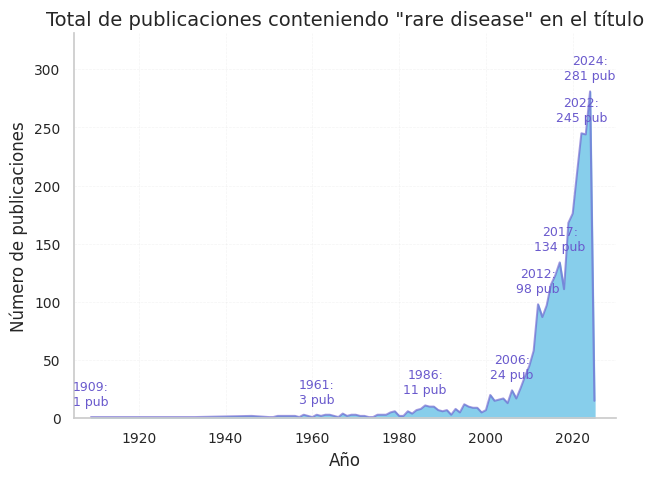

In [ ]:
publicaciones_año = publicaciones.groupby(['pub_year']).size().reset_index(name='count')

x = publicaciones_año['pub_year']
y = publicaciones_año['count']

# Gráfico
plt.figure(figsize=(7, 5))
plt.fill_between(x, y, color="skyblue")
plt.plot(x, y, color="Slateblue", alpha=0.6)
plt.title('Total de publicaciones conteniendo "rare disease" en el título')
plt.xlabel("Año")
plt.ylabel("Número de publicaciones")
plt.xticks(rotation=0)
plt.ylim(0, y.max() + 50)
plt.xlim(1905, 2030)
plt.grid(True, linestyle='--', alpha=0.25)

# Etiquetar picos locales con año y valor
for i in range(len(y)):
    año = x.iloc[i]
    valor = y[i]

    if año in [1909, 1961, 1986]:
        plt.text(año, valor + 10, f"{año}:\n{valor} pub", ha='center', fontsize=9, color='Slateblue')
    elif año >= 1960 and valor > y[i - 1] and valor > y[i + 1] and valor > 20:
        plt.text(año, valor + 10, f"{año}:\n{valor} pub", ha='center', fontsize=9, color='Slateblue')

# Mostrar
plt.show()

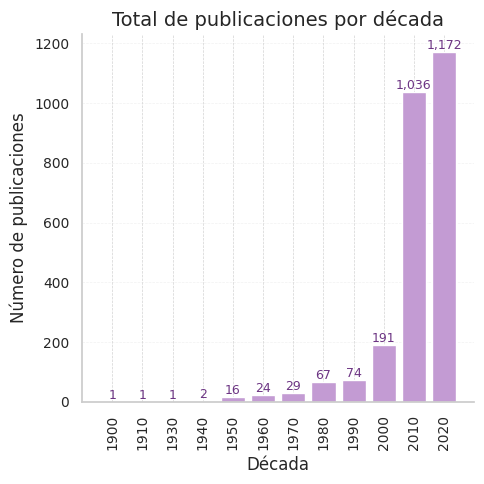

In [ ]:
publicaciones_año['decada'] = (publicaciones_año['pub_year'] // 10) * 10
publicaciones_decada = publicaciones_año.groupby('decada')['count'].sum().reset_index()

plt.figure(figsize=(5, 5))
plt.bar(publicaciones_decada['decada'].astype(str), publicaciones_decada['count'], color='#c39bd3')
plt.title("Total de publicaciones por década")
plt.xlabel("Década")
plt.ylabel("Número de publicaciones")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
# Etiquetas de valores
for i, v in enumerate(publicaciones_decada['count']):
    plt.text(i, v + 10, f"{v:,}", ha='center', fontsize=9, color='#6c3483')

plt.show()

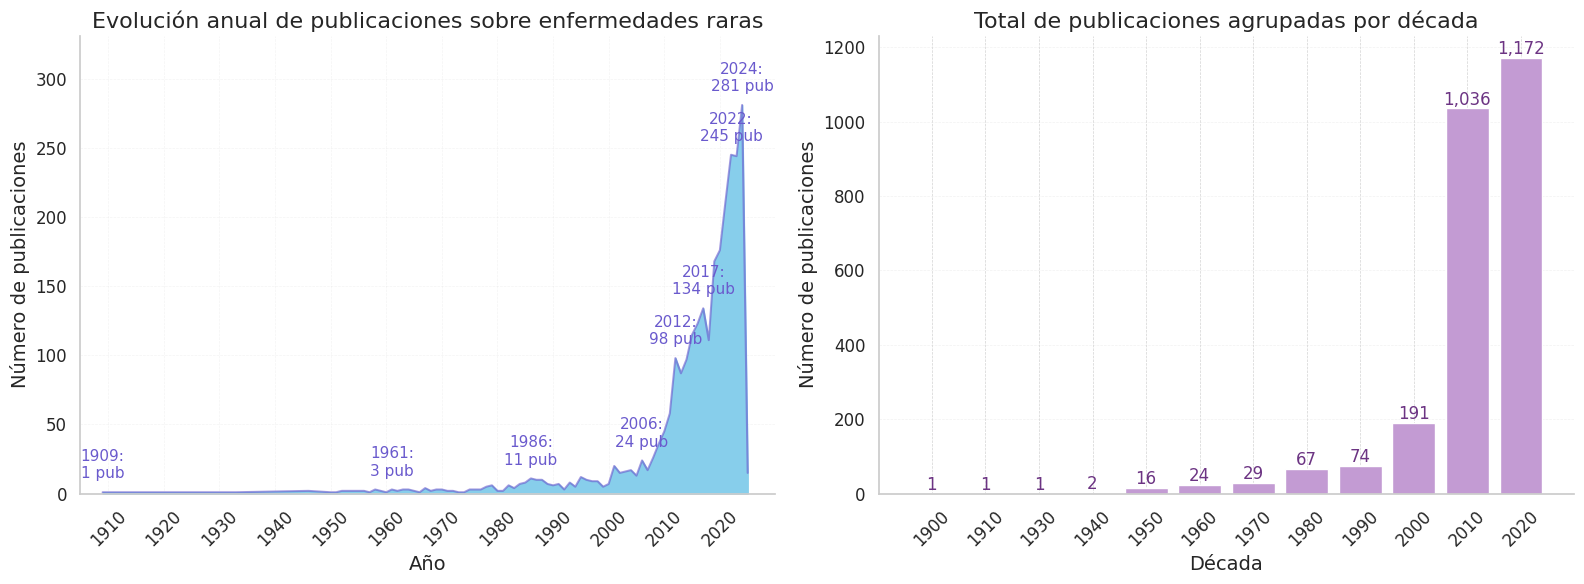

In [ ]:
# Preparar datos
publicaciones_año = publicaciones.groupby(['pub_year']).size().reset_index(name='count')
x = publicaciones_año['pub_year']
y = publicaciones_año['count']

# Agrupar por década
publicaciones_año['decada'] = (publicaciones_año['pub_year'] // 10) * 10
publicaciones_decada = publicaciones_año.groupby('decada')['count'].sum().reset_index()

# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Primera gráfica: publicaciones por año
axes[0].fill_between(x, y, color="skyblue")
axes[0].plot(x, y, color="Slateblue", alpha=0.6)
axes[0].set_title('Evolución anual de publicaciones sobre enfermedades raras', fontsize=16)
axes[0].set_xlabel("Año", fontsize=14)
axes[0].set_ylabel("Número de publicaciones", fontsize=14)
axes[0].set_xticks(range(1910, 2030, 10))
axes[0].tick_params(axis='x', rotation=45, labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_ylim(0, y.max() + 50)
axes[0].set_xlim(1905, 2030)
axes[0].grid(True, linestyle='--', alpha=0.25)

# Etiquetar picos
for i in range(len(y)):
    año = x.iloc[i]
    valor = y[i]
    if año in [1909, 1961, 1986]:
        axes[0].text(año, valor + 10, f"{año}:\n{valor} pub", ha='center', fontsize=11, color='Slateblue')
    elif año >= 1960 and valor > y[i - 1] and valor > y[i + 1] and valor > 20:
        axes[0].text(año, valor + 10, f"{año}:\n{valor} pub", ha='center', fontsize=11, color='Slateblue')

# Segunda gráfica: publicaciones por década
axes[1].bar(publicaciones_decada['decada'].astype(str), publicaciones_decada['count'], color='#c39bd3')
axes[1].set_title("Total de publicaciones agrupadas por década", fontsize=16)
axes[1].set_xlabel("Década", fontsize=14)
axes[1].set_ylabel("Número de publicaciones", fontsize=14)
axes[1].tick_params(axis='x', rotation=45, labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
for i, v in enumerate(publicaciones_decada['count']):
    axes[1].text(i, v + 10, f"{v:,}", ha='center', fontsize=12, color='#6c3483')

plt.tight_layout()
plt.show()

In [ ]:
antes_2010 = publicaciones_año[publicaciones_año['pub_year'] < 2010]['count'].mean()
despues_2010 = publicaciones_año[publicaciones_año['pub_year'] >= 2010]['count'].mean()

print(f"Promedio anual antes de 2010: {antes_2010:.2f}")
print(f"Promedio anual desde 2010: {despues_2010:.2f}")


Promedio anual antes de 2010: 6.44
Promedio anual desde 2010: 138.00


### Distribución de publicaciones por año

Text(0.5, 1.0, 'Distribución de publicaciones por año')

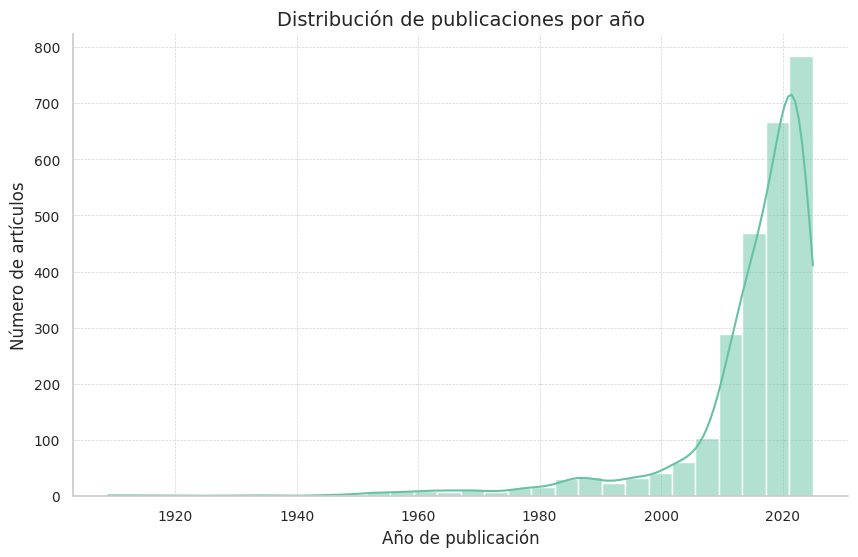

In [ ]:
sns.histplot(data=publicaciones, x='pub_year', bins=30, kde=True)
plt.xlabel('Año de publicación')
plt.ylabel('Número de artículos')
plt.title('Distribución de publicaciones por año')

### Top 5 revistas con más publicaciones

In [ ]:
top_journals = publicaciones['journal'].value_counts().head(5)
print(top_journals)

journal
Orphanet journal of rare diseases                                                      117
BMJ case reports                                                                        51
Cureus                                                                                  48
Genetics in medicine : official journal of the American College of Medical Genetics     26
European journal of human genetics : EJHG                                               21
Name: count, dtype: int64


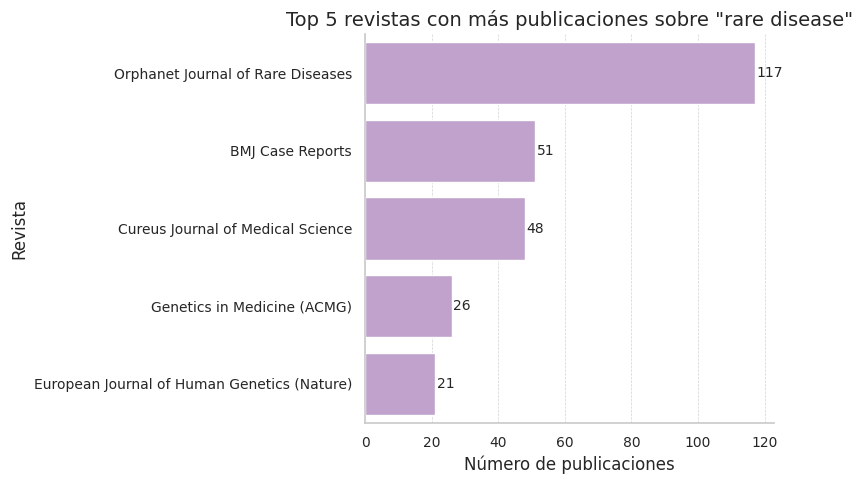

In [ ]:
# Preparar datos
top_journals_df = top_journals.reset_index()
top_journals_df.columns = ['Revista', 'Publicaciones']

# Diccionario con nombres oficiales
nombres_abreviados = {
    'Orphanet journal of rare diseases': 'Orphanet Journal of Rare Diseases',
    'BMJ case reports': 'BMJ Case Reports',
    'Cureus': 'Cureus Journal of Medical Science',
    'Genetics in medicine : official journal of the American College of Medical Genetics': 'Genetics in Medicine (ACMG)',
    'European journal of human genetics : EJHG': 'European Journal of Human Genetics (Nature)'
}

# Aplicar abreviaciones
top_journals_df['Revista'] = top_journals_df['Revista'].map(nombres_abreviados)

# Crear gráfico
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=top_journals_df, y='Revista', x='Publicaciones', color='#c39bd3')

# Añadir etiquetas de número de publicaciones al final de cada barra
for i, (valor, revista) in enumerate(zip(top_journals_df['Publicaciones'], top_journals_df['Revista'])):
    ax.text(valor + 0.5, i, str(valor), va='center', fontsize=10)

# Estética
plt.title('Top 5 revistas con más publicaciones sobre "rare disease"')
plt.xlabel('Número de publicaciones')
plt.ylabel('Revista')
plt.tight_layout()
plt.show()

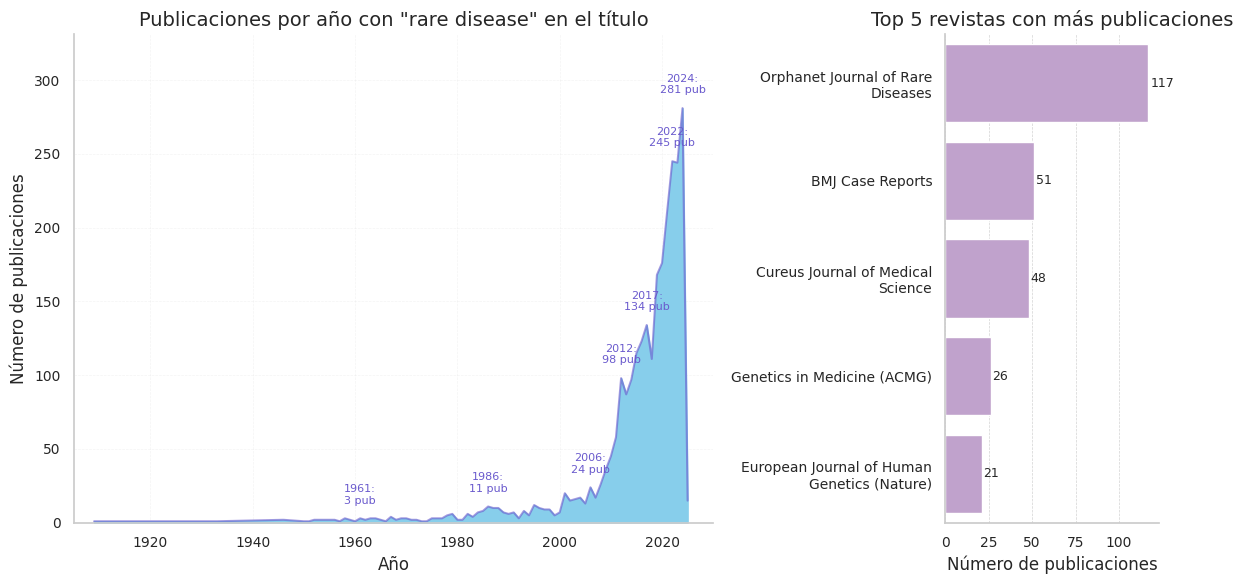

In [ ]:
# --- Datos para gráfico 1: evolución anual ---
publicaciones_año = publicaciones.groupby(['pub_year']).size().reset_index(name='count')
x = publicaciones_año['pub_year']
y = publicaciones_año['count']

# --- Datos para gráfico 2: top 5 revistas ---
top_journals_df = top_journals.reset_index()
top_journals_df.columns = ['Revista', 'Publicaciones']

# Nombres oficiales
nombres_abreviados = {
    'Orphanet journal of rare diseases': 'Orphanet Journal of Rare Diseases',
    'BMJ case reports': 'BMJ Case Reports',
    'Cureus': 'Cureus Journal of Medical Science',
    'Genetics in medicine : official journal of the American College of Medical Genetics': 'Genetics in Medicine (ACMG)',
    'European journal of human genetics : EJHG': 'European Journal of Human Genetics (Nature)'
}
top_journals_df['Revista'] = top_journals_df['Revista'].map(nombres_abreviados)

# Envolver nombres de revistas en dos líneas (máx 30 caracteres por línea)
top_journals_df['Revista'] = top_journals_df['Revista'].apply(
    lambda x: '\n'.join(textwrap.wrap(x, width=30))
)

# --- Crear subplots horizontales ---
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 6),
    gridspec_kw={'width_ratios': [3, 1]}  # Primer gráfico 3 veces más ancho
)

# --- Gráfico 1: publicaciones por año ---
axes[0].fill_between(x, y, color="skyblue")
axes[0].plot(x, y, color="Slateblue", alpha=0.6)
axes[0].set_title('Publicaciones por año con "rare disease" en el título')
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Número de publicaciones")
axes[0].set_xlim(1905, 2030)
axes[0].set_ylim(0, y.max() + 50)
axes[0].grid(True, linestyle='--', alpha=0.25)

# Etiquetas de años clave
for i in range(1, len(y) - 1):
    año = x.iloc[i]
    valor = y[i]
    if año in [1909, 1961, 1986]:
        axes[0].text(año, valor + 10, f"{año}:\n{valor} pub", ha='center', fontsize=8, color='Slateblue')
    elif año >= 1960 and valor > y[i - 1] and valor > y[i + 1] and valor > 20:
        axes[0].text(año, valor + 10, f"{año}:\n{valor} pub", ha='center', fontsize=8, color='Slateblue')

# --- Gráfico 2: top revistas (barras horizontales) ---
sns.barplot(data=top_journals_df, y='Revista', x='Publicaciones', color='#c39bd3', ax=axes[1])
axes[1].set_title('Top 5 revistas con más publicaciones')
axes[1].set_xlabel('Número de publicaciones')
axes[1].set_ylabel('')  # Ya están en eje Y

# Etiquetas al final de cada barra
for i, (valor, revista) in enumerate(zip(top_journals_df['Publicaciones'], top_journals_df['Revista'])):
    axes[1].text(valor + 1, i, str(valor), va='center', fontsize=9)

# Ajustar diseño
plt.tight_layout()
plt.show()
